# App-25 — Enchères combinatoires : Winner Determination à grande échelle et audit des garanties VCG

> **Navigation** : [Applications Search](../README.md) · [GameTheory — théorie des mécanismes](../../../GameTheory/README.md) · [CSP-3 (CP-SAT avancé)](../../Part2-CSP/CSP-3-Advanced.ipynb)

## Objectifs d'apprentissage

À la fin de ce notebook, vous saurez :

1. modéliser le *Winner Determination Problem* (WDP) comme un **set packing pondéré** et le résoudre exactement en CP-SAT ;
2. mesurer le **mur de la force brute** ($2^n$ sous-ensembles) face à la propagation CP-SAT, jusqu'aux instances réelles du générateur **CATS** (Leyton-Brown 2000) ;
3. décoder la sémantique **XOR** (dummy goods CATS) et **budget global** sur les prix déclarés ;
4. exécuter l'**audit computationnel de VCG** — rationalité individuelle, perdants à paiement nul, no-deficit, optimalité de chaque sous-résolution — y compris à l'échelle d'une instance CATS ;
5. **matérialiser un contre-exemple documenté** : VCG avec contrainte de budget n'est pas truthful (surplus 7 contre 0), alors que trois propriétés survivent mécaniquement ;
6. lire un artefact numérique avec un œil forensique : le mismatch `PRICE_SCALE`/`bid_alpha` des outputs étudiants.

**Prérequis** : [CSP-3 (CP-SAT)](../../Part2-CSP/CSP-3-Advanced.ipynb), bases de théorie des mécanismes ([GameTheory-16](../../../GameTheory/GameTheory-16-MechanismDesign.ipynb)). **Durée estimée** : 60 min.

## Hommage à un travail étudiant

Ce notebook distille le projet **J2** du cours EPITA SCIA *Programmation par Contraintes* 2026, réalisé par **Lucas Majerczyk** ([Sosolalt](https://github.com/Sosolalt)), **Nabil Chartouni** ([NCH04](https://github.com/NCH04)) et **Wilfrid Wangon-Zekou** ([56Nights](https://github.com/56Nights)) :

- [répertoire source — `Groupe-J2-Enchere_combinatoire_et_Winner_Determination`](https://github.com/jsboigeEpita/2026-Epita-Programmation-par-Contraintes/tree/main/Groupe-J2-Enchere_combinatoire_et_Winner_Determination) ;
- [PR source #26](https://github.com/jsboigeEpita/2026-Epita-Programmation-par-Contraintes/pull/26), licence MIT, commit `b5f3f035`.

L'appareil étudiant apporte le geste central — *set packing CP-SAT exact + sémantique XOR/budget + CATS officiel + VCG en deux régimes* — avec 44 tests pytest (re-passés 44/44 au commit source lors de cette distillation) et quatre notes de recherche dont le contre-exemple de manipulation sous budget. CoursIA réécrit l'expérience de façon autonome : ré-implémentation indépendante (prix **entiers milli-unités bout-en-bout**), re-résolution fraîche des 18 instances CATS, **matérialisation exécutable** du contre-exemple (documenté mais promis comme test absent du dépôt source), et forensics de l'artefact `PRICE_SCALE` (§7). Les corrections et limites restent visibles : la borne greedy $\sqrt{m}$ **ne s'applique pas** ici (§8), et la truthfulness de VCG est un théorème que ce notebook instancie — pas une preuve.

## 1. Environnement et contrat reproductible

Toutes les cellules de ce notebook sont **déterministes** : le solveur CP-SAT est exact (pas d'aléa), le seul générateur pseudo-aléatoire (instances du mur de force brute, §2.3) est semé à 42, et les données CATS sont des fichiers locaux copiés dans `data/app25-wdp-vcg-audit/` — le notebook ne dépend **pas** du dépôt source à l'exécution. Le snapshot `cats_snapshot.json` sépare explicitement les **outputs committés par les étudiants** (`student_reported`) des **vérifications indépendantes CoursIA**.

In [1]:
import json
import math
import random
import sys
import time
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
from ortools.sat.python import cp_model


def data_dir():
    """Ancrage des donnees (robuste au cwd d'execution)."""
    here = Path.cwd()
    for base in (here, here.parent, here.parent.parent):
        cand = base / "data" / "app25-wdp-vcg-audit"
        if (cand / "cats_snapshot.json").exists():
            return cand
    return here / "data" / "app25-wdp-vcg-audit"


DATA = data_dir()
SNAP = json.loads((DATA / "cats_snapshot.json").read_text(encoding="utf-8"))

print(f"Python {sys.version.split()[0]} | ortools {__import__('ortools').__version__} | pandas {pd.__version__}")
print(f"Donnees locales : {DATA.name}/ ({len(SNAP['cats'])} instances CATS)")
meta = SNAP["meta"]
print(f"Source           : {meta['source_repo']} @ {meta['source_commit'][:8]}")
print(f"Auteurs          : {', '.join(meta['authors'])} (MIT)")
print(f"Tests source     : {SNAP['source_tests']['passed']}/{SNAP['source_tests']['collected']} passants, re-executes au commit source")

Python 3.13.14 | ortools 9.15.6755 | pandas 2.3.3
Donnees locales : app25-wdp-vcg-audit/ (18 instances CATS)
Source           : jsboigeEpita/2026-Epita-Programmation-par-Contraintes @ b5f3f035
Auteurs          : Lucas Majerczyk, Nabil Chartouni, Wilfrid Wangon-Zekou (MIT)
Tests source     : 44/44 passants, re-executes au commit source


**Interprétation.** Le contrat est reproductible : environnement affiché, commit source épinglé (`b5f3f035`), tests source re-passés à 44/44, et 18 instances CATS disponibles localement. Aucune cellule n'a besoin d'un accès réseau ou du dépôt PrCon.

## 2. Le WDP : de l'énumération de GameTheory au set packing CP-SAT

Le **Winner Determination Problem** : étant donné $m$ items et $n$ offres (l'offre $j$ porte sur un bundle $S_j$ au prix $p_j$), choisir l'ensemble d'offres gagnantes qui **maximise le revenu** $\sum_j p_j x_j$ sous exclusivité d'item — chaque item va à au plus un gagnant (hypothèse de *free disposal* côté vendeur, Cramton-Shoham-Steinberg 2006 ch. 1 : un item peut rester invendu). C'est un **set packing pondéré**, NP-difficile (Rothkopf-Pekeč-Harstad 1998 ; Sandholm 2002).

CoursIA résout déjà le VCG combinatoire **par énumération exhaustive des allocations** — [`examples/vcg_auction.py`](../../../GameTheory/examples/vcg_auction.py) parcourt le powerset des bundles, et [GameTheory-16 §4.5](../../../GameTheory/GameTheory-16-MechanismDesign.ipynb) énumère les affectations d'objets à la main pour 2 objets. Ce notebook montre où cette approche meurt, et ce qui la remplace.

### 2.1 L'instance jouet, résolue par énumération exhaustive

L'instance `toy_example` du projet J2 : 3 items (Paris, Lyon, Marseille), 5 offres. Énumérons littéralement les $2^5 = 32$ sous-ensembles d'offres — exactement le geste de `vcg_auction.py`, transposé au set packing.

In [2]:
class Instance:
    """Instance de set packing. Tous les prix sont des ENTIERS dans une
    unite commune (milli-unites CATS ou unites entieres pedagogiques)."""

    def __init__(self, name, items, bids, xor_groups=(), global_cap=None,
                 price_divisor=1):
        self.name = name
        self.items = list(items)
        self.bids = list(bids)          # (id, bidder, frozenset(items), prix int)
        self.xor_groups = [list(g) for g in xor_groups]
        self.global_cap = global_cap    # meme unite que les prix
        self.price_divisor = price_divisor


TOY = Instance(
    "toy_example", ["P", "L", "M"],
    [(0, "Alice", frozenset({"P", "L"}), 25),
     (1, "Bob",   frozenset({"L", "M"}), 22),
     (2, "Carol", frozenset({"P", "M"}), 20),
     (3, "David", frozenset({"P", "L", "M"}), 40),
     (4, "Eve",   frozenset({"P"}), 15)])


def brute_force_wdp(inst, enforce_budget=True, enforce_xor=True):
    """Enumere les 2^n sous-ensembles d'offres (le geste vcg_auction.py)."""
    bids, n = inst.bids, len(inst.bids)
    items_of = [it for _b, _bd, it, _p in bids]
    xor_index = {}
    for k, grp in enumerate(inst.xor_groups):
        for b in grp:
            xor_index[b] = k
    best_rev, best_set = 0, ()
    for mask in range(1 << n):
        used, used_xor, rev, ok = set(), set(), 0, True
        for j in range(n):
            if not (mask >> j) & 1:
                continue
            if items_of[j] & used:
                ok = False
                break
            k = xor_index.get(bids[j][0])
            if enforce_xor and k is not None and k in used_xor:
                ok = False
                break
            if (enforce_budget and inst.global_cap is not None
                    and rev + bids[j][3] > inst.global_cap):
                ok = False
                break
            used |= items_of[j]
            if k is not None:
                used_xor.add(k)
            rev += bids[j][3]
        if ok and rev > best_rev:
            best_rev, best_set = rev, tuple(bids[j][0] for j in range(n) if (mask >> j) & 1)
    return best_rev, best_set


rev_bf, winners_bf = brute_force_wdp(TOY)
bidder_of = {b: bd for b, bd, _it, _p in TOY.bids}
print(f"toy_example : {len(TOY.bids)} offres -> {2**len(TOY.bids)} sous-ensembles enumeres")
print(f"Optimum par force brute : {rev_bf} (offres {list(winners_bf)}, "
      f"gagnant {[bidder_of[b] for b in winners_bf]})")

toy_example : 5 offres -> 32 sous-ensembles enumeres
Optimum par force brute : 40 (offres [3], gagnant ['David'])


**Interprétation.** L'optimum est **40** : David emporte le tout-with-everything `{P,L,M}`, devant `Bob+Eve` (22+15 = 37) et Alice seule (25) — et `Alice+Eve` n'est même pas faisable (toutes deux veulent P) : c'est tout l'intérêt de l'énumération exhaustive, elle rend ces alternatives visibles. Trente-deux sous-ensembles, c'est trivial ; le coût est **exponentiel en le nombre d'offres**, pas en le nombre d'items.

### 2.2 Le modèle CP-SAT : set packing pondéré

Variables $x_j \in \{0,1\}$, objectif $\max \sum_j p_j x_j$, contraintes : (1) exclusivité d'item $\sum_{j \ni i} x_j \le 1$ ; (2) budget global optionnel $\sum_j p_j x_j \le C$ — exprimé **en prix déclarés** (ce point deviendra central au §6) ; (3) groupes XOR optionnels $\sum_{j \in G} x_j \le 1$. C'est la même famille de modèles que [CSP-3](../../Part2-CSP/CSP-3-Advanced.ipynb) et [CSP-5](../../Part2-CSP/CSP-5-Optimization.ipynb).

In [3]:
def solve_wdp(inst, enforce_budget=True, enforce_xor=True,
              excluded_bidders=frozenset(), time_limit_s=30.0):
    """Set packing exact par CP-SAT. Les prix restent entiers : aucun
    aller-retour flottant, donc aucune perte de precision possible."""
    model = cp_model.CpModel()
    x = {}
    for b, bidder, _items, _p in inst.bids:
        if bidder not in excluded_bidders:
            x[b] = model.new_bool_var(f"x{b}")
    for item in inst.items:
        covering = [x[b] for b, _bd, it, _p in inst.bids
                    if b in x and item in it]
        if len(covering) >= 2:
            model.add_at_most_one(covering)
    if enforce_budget and inst.global_cap is not None:
        model.add(sum(p * x[b] for b, _bd, _it, p in inst.bids if b in x)
                  <= inst.global_cap)
    if enforce_xor:
        for group in inst.xor_groups:
            gv = [x[b] for b in group if b in x]
            if len(gv) >= 2:
                model.add_at_most_one(gv)
    model.maximize(sum(p * x[b] for b, _bd, _it, p in inst.bids if b in x))
    solver = cp_model.CpSolver()
    solver.parameters.max_time_in_seconds = time_limit_s
    t0 = time.perf_counter()
    status = solver.solve(model)
    elapsed = time.perf_counter() - t0
    names = {cp_model.OPTIMAL: "OPTIMAL", cp_model.FEASIBLE: "FEASIBLE",
             cp_model.INFEASIBLE: "INFEASIBLE", cp_model.UNKNOWN: "UNKNOWN"}
    if status in (cp_model.OPTIMAL, cp_model.FEASIBLE):
        winners = sorted(b for b, v in x.items() if solver.value(v) == 1)
        revenue = int(round(solver.objective_value))
    else:
        winners, revenue = [], 0
    return {"winners": winners, "revenue_int": revenue,
            "status": names.get(status, f"STATUS_{status}"),
            "solve_time_s": elapsed, "n_vars": len(x)}


r_toy = solve_wdp(TOY)
print(f"CP-SAT sur toy_example : revenu {r_toy['revenue_int']} "
      f"({r_toy['status']}, {r_toy['n_vars']} variables booleennes)")
print(f"Accord force brute == CP-SAT : {r_toy['revenue_int'] == rev_bf}")

CP-SAT sur toy_example : revenu 40 (OPTIMAL, 5 variables booleennes)
Accord force brute == CP-SAT : True


**Interprétation.** CP-SAT retrouve le **40** de la force brute avec un statut `OPTIMAL` — c'est une **preuve d'optimalité** délivrée par le solveur pour cette instance, pas une heuristique. Avec 5 offres, les deux méthodes se valent ; la suite mesure où cela cesse d'être vrai.

### 2.3 Le mur : $2^n$ contre la propagation

Générons (graine 42, reproductible) des instances de set packing croissantes et comparons l'énumération exhaustive au CP-SAT. Chaque paire (force brute, CP-SAT) doit trouver le **même optimum** — c'est la validation croisée des deux implémentations.

,n_offres,sous_ensembles,n_items,brute_force_s,cp_sat_s,optimum
0,10,1024,5,0.0036,0.0193,86
1,12,4096,6,0.0074,0.0192,165
2,14,16384,7,0.0240,0.0036,169
3,16,65536,8,0.0504,0.0148,228
4,18,262144,9,0.1479,0.0066,178
5,20,1048576,10,1.2639,0.0087,266


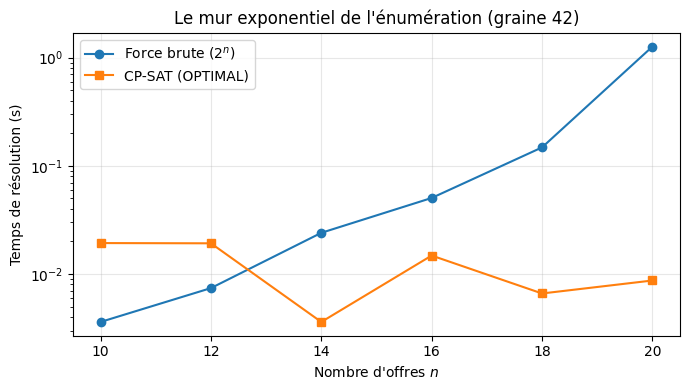

In [4]:
rng = random.Random(42)
wall_rows = []
for n in (10, 12, 14, 16, 18, 20):
    m = max(4, n // 2)
    bids = []
    for j in range(n):
        bundle = frozenset(f"i{rng.randrange(m)}" for _ in range(rng.randint(1, 3)))
        bids.append((j, f"b{j}", bundle, rng.randint(5, 60)))
    inst = Instance(f"rand{n}", [f"i{i}" for i in range(m)], bids)
    t0 = time.perf_counter()
    rev_bf_i, _ = brute_force_wdp(inst)
    t_bf = time.perf_counter() - t0
    r_i = solve_wdp(inst, enforce_budget=False, enforce_xor=False)
    assert rev_bf_i == r_i["revenue_int"], f"desaccord n={n}"
    wall_rows.append({"n_offres": n, "sous_ensembles": 2 ** n, "n_items": m,
                      "brute_force_s": round(t_bf, 4),
                      "cp_sat_s": round(r_i["solve_time_s"], 4),
                      "optimum": rev_bf_i})
wall = pd.DataFrame(wall_rows)
display(wall)

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(wall["n_offres"], wall["brute_force_s"], "o-", label="Force brute ($2^n$)")
ax.plot(wall["n_offres"], wall["cp_sat_s"], "s-", label="CP-SAT (OPTIMAL)")
ax.set_yscale("log")
ax.set_xlabel("Nombre d'offres $n$")
ax.set_ylabel("Temps de résolution (s)")
ax.set_title("Le mur exponentiel de l'énumération (graine 42)")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

**Interprétation.** Sur la plage mesurée, la force brute double environ à chaque offre ajoutée — $2^{20} = 1\,048\,576$ sous-ensembles sur la dernière ligne du tableau — tandis que CP-SAT reste dans le même ordre de grandeur (le rapport entre les deux colonnes de temps se lit dans le tableau). L'extrapolation est sans appel : les instances CATS de ce notebook ont **100 à 204 offres**, soit $2^{100} \approx 1{,}3 \times 10^{30}$ sous-ensembles — l'énumération de `vcg_auction.py` est morte bien avant CATS. Ce que CP-SAT apporte n'est pas une astuce mais la **propagation de contraintes** (Partie 2 du cours) : chaque item déjà pris élimine toute une branche. Les temps absolus restent dans les outputs (machine-dépendants) ; l'ordre de grandeur structurel, lui, est une invariante.

## 3. Sémantique XOR et budget : le langage des offres

Le projet J2 nomme son langage : **XOR par bidder** (Nisan 2000, §3 — chaque bidder déclare une clause XOR, au plus une de ses offres gagne ; l'agrégation entre bidders est un OR implicite). Les contraintes de budget (global, et par bidder dans le code source) s'expriment sur les **prix déclarés** : $\sum_j p_j x_j \le C$. Prenons les deux instances pédagogiques du projet, plus une mini-instance CoursIA où la contrainte XOR **mord** vraiment.

In [5]:
WITH_BUDGET = Instance(
    "with_budget", list("ABCDEF"),
    [(0, "Alice", frozenset({"A", "B"}), 30),
     (1, "Alice", frozenset({"C", "D"}), 28),
     (2, "Bob",   frozenset({"B", "C"}), 25),
     (3, "Bob",   frozenset({"E", "F"}), 22),
     (4, "Carol", frozenset({"A", "D", "E"}), 40),
     (5, "David", frozenset({"A", "B", "C", "D"}), 55),
     (6, "David", frozenset({"E", "F"}), 18)],
    xor_groups=[[0, 1], [2, 3], [5, 6]], global_cap=50)

WITH_XOR = Instance(
    "with_xor", list("XYZWV"),
    [(0, "Alice", frozenset({"X"}), 12),
     (1, "Alice", frozenset({"X", "Y"}), 25),
     (2, "Alice", frozenset({"X", "Y", "Z"}), 35),
     (3, "Bob",   frozenset({"W"}), 10),
     (4, "Bob",   frozenset({"W", "V"}), 22),
     (5, "Carol", frozenset({"Z", "W"}), 20),
     (6, "Carol", frozenset({"Y", "Z", "W", "V"}), 38)],
    xor_groups=[[0, 1, 2], [3, 4], [5, 6]])

# Mini-instance CoursIA : deux offres DISJOINTES du meme bidder.
# L'exclusivite d'item ne peut pas les rendre exclusives ; XOR oui.
XOR_BITE = Instance(
    "xor_bite", ["A", "B"],
    [(0, "Alice", frozenset({"A"}), 10),
     (1, "Alice", frozenset({"B"}), 10),
     (2, "Bob",   frozenset({"A", "B"}), 15)],
    xor_groups=[[0, 1]])

rows = []
for label, inst, kw in [
    ("with_budget — sans contraintes", WITH_BUDGET, dict(enforce_budget=False, enforce_xor=False)),
    ("with_budget — budget+XOR",       WITH_BUDGET, {}),
    ("with_xor — sans XOR",            WITH_XOR, dict(enforce_xor=False)),
    ("with_xor — avec XOR",            WITH_XOR, {}),
    ("xor_bite — sans XOR (CoursIA)",  XOR_BITE, dict(enforce_xor=False)),
    ("xor_bite — avec XOR (CoursIA)",  XOR_BITE, {}),
]:
    r = solve_wdp(inst, **kw)
    rows.append({"cas": label, "revenu": r["revenue_int"],
                 "statut": r["status"], "offres_gagnantes": r["winners"]})
display(pd.DataFrame(rows))

,cas,revenu,statut,offres_gagnantes
0,with_budget — sans contraintes,80,OPTIMAL,"[0, 1, 3]"
1,with_budget — budget+XOR,50,OPTIMAL,"[1, 3]"
2,with_xor — sans XOR,57,OPTIMAL,"[2, 4]"
3,with_xor — avec XOR,57,OPTIMAL,"[2, 4]"
4,xor_bite — sans XOR (CoursIA),20,OPTIMAL,"[0, 1]"
5,xor_bite — avec XOR (CoursIA),15,OPTIMAL,[2]


**Interprétation.** Trois phénomènes distincts. (1) **Budget** : sur `with_budget`, l'optimum chute de **80 à 50** quand le cap global devient actif — la contrainte lie, et elle s'exprime en prix déclarés. (2) **XOR** : sur `xor_bite`, sans XOR les deux offres disjointes d'Alice (10+10 = 20) battent Bob (15) ; avec XOR, Alice n'en garde qu'une et **Bob l'emporte à 15** — la contrainte XOR est une exclusivité **logique entre offres disjointes**, que l'exclusivité d'item ne peut pas coder. (3) Sur `with_xor`, l'optimum vaut **57 avec ou sans XOR** (offres 2 et 4 : Alice 35 + Bob 22) : les groupes XOR y sont impliqués par le recouvrement d'items, donc non-actifs sur cet optimum — il faut le vérifier, pas le supposer.

### 3.2 CATS : dummy goods et reconstruction du OR-of-XOR

Le générateur **CATS** (Leyton-Brown-Pearson-Shoham, EC 2000) écrit ses instances dans un format texte : en-tête `goods/bids/dummy`, puis une ligne par offre. Les *dummy goods* (ids $\ge$ `goods`) encodent l'XOR : deux offres partageant un dummy sont mutuellement exclusives — ce qui permet à CATS d'exprimer du **OR-of-XOR** (plusieurs clauses XOR par agent) sans toucher au WDP. Les prix sont des **entiers bruts** du flag `-int_prices` ; la valeur en unités = brut / `bid_alpha` (défaut CATS 1000, **non consigné dans le fichier** — on y revient en §7).

In [6]:
def parse_cats_text(text):
    """Parse un fichier CATS. Les prix restent en entiers bruts (milli-unites)."""
    header, rows = {}, []
    for raw in text.splitlines():
        line = raw.strip()
        if not line or line.startswith("%"):
            continue
        parts = line.split()
        if len(parts) == 2 and parts[0] in {"goods", "bids", "dummy"}:
            header[parts[0]] = int(parts[1])
            continue
        if line.endswith("#"):
            line = line[:-1].rstrip()
            parts = line.split()
        rows.append((int(parts[0]), int(parts[1]), [int(t) for t in parts[2:]]))
    n_real = header["goods"]
    by_dummy = {}
    for b, _p, goods in rows:
        for g in goods:
            if g >= n_real:
                by_dummy.setdefault(g, []).append(b)
    xor_groups = sorted(sorted(v) for v in by_dummy.values() if len(v) >= 2)
    return {"n_real": n_real, "n_bids": header["bids"], "n_dummy": header["dummy"],
            "bids": rows, "xor_groups": xor_groups}


def cats_to_instance(parsed, name):
    bids = []
    for b, p, goods in parsed["bids"]:
        real_goods = frozenset(f"i{g}" for g in goods if g < parsed["n_real"])
        dummy_goods = [g for g in goods if g >= parsed["n_real"]]
        # CATS attache au plus un dummy a une offre. Les offres qui partagent ce
        # dummy appartiennent a la meme clause XOR (donc au meme bidder) ; une
        # offre sans dummy est une declaration single-minded independante.
        assert len(dummy_goods) <= 1, f"offre CATS {b}: plusieurs dummy goods"
        bidder = f"dummy-{dummy_goods[0]}" if dummy_goods else f"single-{b}"
        bids.append((b, bidder, real_goods, p))
    return Instance(name, [f"i{i}" for i in range(parsed["n_real"])], bids,
                    parsed["xor_groups"], price_divisor=1000)


CATS_LIVE = {}
for fname in ["regions_g30_b100_s10000", "paths_g30_b100_s10000",
              "matching_g32_b100_s10000"]:
    parsed = parse_cats_text((DATA / "cats" / f"{fname}.txt").read_text())
    inst = cats_to_instance(parsed, fname)
    CATS_LIVE[fname] = (parsed, inst)
    r = solve_wdp(inst)
    snap_row = next(c for c in SNAP["cats"] if c["instance"] == fname)
    print(f"{fname:28s} goods={parsed['n_real']:>3d} dummy={parsed['n_dummy']:>3d} "
          f"offres={len(parsed['bids']):>3d} xor={len(parsed['xor_groups']):>2d} "
          f"| CP-SAT live {r['revenue_int']/1000:>9.3f} ({r['status']}) "
          f"| snapshot {snap_row['revenue_value_units']:>9.3f} "
          f"| ecart {abs(r['revenue_int'] - snap_row['revenue_int']):d} milli-u")

regions_g30_b100_s10000      goods= 30 dummy= 19 offres=104 xor=19 | CP-SAT live  2114.569 (OPTIMAL) | snapshot  2114.569 | ecart 0 milli-u
paths_g30_b100_s10000        goods= 30 dummy= 31 offres=100 xor=25 | CP-SAT live    13.125 (OPTIMAL) | snapshot    13.125 | ecart 0 milli-u
matching_g32_b100_s10000     goods= 32 dummy= 31 offres=106 xor=19 | CP-SAT live    64.213 (OPTIMAL) | snapshot    64.213 | ecart 0 milli-u


**Interprétation.** Les trois instances vivent à l'échelle visée (100 à 106 offres) et la résolution **en direct** retrouve exactement les optima du snapshot (écart 0 milli-unité) — le snapshot n'est pas une dépendance, c'est un **témoin**. Les comptes `offres`/`xor` correspondent aussi aux valeurs étudiants archivées. Sur la structure : `regions` (grille géométrique, enchères de spectre) porte 30 items réels et 19 dummies, chacun partagé — d'où 19 groupes XOR reconstruits ; `paths` reconstitue 25 groupes à partir de 31 dummies. Chaque dummy partagé est une clause d'exclusivité que l'exclusivité d'item seule ne peut pas exprimer entre offres disjointes.

### Exercice 1 — Reconstruire le XOR depuis les dummy goods

La chaîne `MINI` ci-dessous encode un mini-CATS de 2 items réels (0, 1) et 3 dummy goods (2, 3, 4). Reconstruisez ses groupes XOR **à la main** (sans `parse_cats_text`) : deux offres partageant un dummy sont exclusives, un dummy porté par une seule offre n'en fait pas un. Combien de groupes obtenez-vous ?

**Indice :** parcourez les dummy goods, pas les offres.

**Etapes :** 1) indexer les offres par dummy good ; 2) ne garder que les dummies partages par >= 2 offres.

In [7]:
MINI = """
goods 2
bids 5
dummy 3

0 100 0 2 #
1 150 1 2 #
2 90 0 3 #
3 80 1 3 4 #
4 70 1 4 #
"""

# TODO étudiant : remplir xor_groups_mini (liste triée de listes d'ids d'offres).
xor_groups_mini = None  # attendu : un groupe par dummy partagé par >= 2 offres
print("Exercice à compléter")

Exercice à compléter


**Point de contrôle.** La bonne réponse compte **3 groupes** : les offres 0 et 1 partagent le dummy 2, les offres 2 et 3 partagent le dummy 3, et les offres 3 et 4 partagent le dummy 4. L'offre 3 appartient donc à deux clauses XOR distinctes — la reconstruction conserve un groupe par dummy partagé, sans fusion transitive. Comparez votre réponse à `parse_cats_text(MINI)["xor_groups"]`.

## 4. Les 18 instances CATS : outputs étudiants contre vérification indépendante

Le projet J2 a committé son notebook **exécuté** : chaque instance CATS y apparaît avec son revenu CP-SAT (`rev_cp`) et PLNE (`rev_milp`). Ces outputs sont la **propriété intellectuelle des étudiants** — le snapshot les archive sous `student_reported`. À côté, la colonne CoursIA est notre **re-résolution indépendante** (implémentation du §2, milli-entiers). Les deltas sont exprimés en **milli-unités** (1 milli-unité = 1/1000 d'unité de valeur).

In [8]:
rows = []
for c in SNAP["cats"]:
    rows.append({
        "instance": c["instance"], "dist": c["distribution"],
        "offres": c["n_bids"], "xor": c["n_xor_groups"],
        "statut": c["status"],
        "etudiant_cp": c["student_reported"]["rev_cp"],
        "etudiant_milp": c["student_reported"]["rev_milp"],
        "coursia_exact": c["revenue_value_units"],
        "d_cp_mU": c["delta_student_cp_milli_units"],
        "d_milp_mU": c["delta_student_milp_milli_units"],
        "gagnants": c["n_winners"],
    })
cats_df = pd.DataFrame(rows)
n_status = (cats_df["statut"] == "OPTIMAL").sum()
n_milp_ok = (cats_df["d_milp_mU"].abs() <= 5).sum()
n_cp_ko = (cats_df["d_cp_mU"].abs() > 5).sum()
print(f"Statuts OPTIMAL (CoursIA) : {n_status}/18 | "
      f"PLNE etudiants == exact (a l'affichage pres) : {n_milp_ok}/18 | "
      f"CP-SAT etudiants en ecart : {n_cp_ko}/18 "
      f"(max |delta| {cats_df['d_cp_mU'].abs().max()} mU)")
display(cats_df)

Statuts OPTIMAL (CoursIA) : 18/18 | PLNE etudiants == exact (a l'affichage pres) : 18/18 | CP-SAT etudiants en ecart : 10/18 (max |delta| 25 mU)


,instance,dist,offres,xor,statut,etudiant_cp,etudiant_milp,coursia_exact,d_cp_mU,d_milp_mU,gagnants
0,arbitrary_g30_b100_s10000,arbitrary,100,20,OPTIMAL,1958.65,1958.65,1958.653,-3,-3,1
1,arbitrary_g30_b100_s20000,arbitrary,100,18,OPTIMAL,1402.22,1402.21,1402.207,13,3,7
2,arbitrary_g30_b100_s30000,arbitrary,101,19,OPTIMAL,1998.51,1998.51,1998.513,-3,-3,4
3,matching_g32_b100_s10000,matching,106,19,OPTIMAL,64.21,64.21,64.213,-3,-3,10
4,matching_g32_b100_s20000,matching,108,14,OPTIMAL,69.16,69.17,69.173,-13,-3,10
5,matching_g32_b100_s30000,matching,103,16,OPTIMAL,91.14,91.14,91.144,-4,-4,10
6,paths_g30_b100_s10000,paths,100,25,OPTIMAL,13.10,13.12,13.125,-25,-5,19
7,paths_g30_b100_s20000,paths,101,21,OPTIMAL,11.82,11.83,11.829,-9,1,20
8,paths_g30_b100_s30000,paths,100,24,OPTIMAL,15.25,15.27,15.268,-18,2,18
9,paths_g60_b200_s10000,paths,201,49,OPTIMAL,22.09,22.10,22.102,-12,-2,28


**Interprétation.** Les statuts confirment : **18/18 OPTIMAL** en CP-SAT — chaque ligne porte une preuve finie d'optimalité. Les revenus **PLNE committés** par les étudiants coïncident avec notre calcul exact sur 18/18 (à l'arrondi d'affichage près : l'optimum exact de `paths_g30_b100_s10000` est 13.125, affiché 13.12). Mais **10 lignes sur 18** voient le CP-SAT committé s'écarter de l'optimum exact de 6 à 25 milli-unités — un écart minuscule en valeur, mais systématique. Le §7 l'explique par forensics : ce n'est pas le solveur, c'est un **artefact d'échelle** dans le pipeline de prix.

### 4.1 Agrégats par distribution

Les 18 instances couvrent 5 distributions économiquement motivées de Leyton-Brown 2000 (`arbitrary`, `matching`, `paths`, `regions`, `scheduling`) — 3 graines chacune à ~30 items, plus 4 instances à 60-64 items.

In [9]:
agg = (cats_df.groupby("dist", sort=False)
       .agg(n=("instance", "count"),
            offres_moy=("offres", "mean"),
            xor_moy=("xor", "mean"),
            gagnants_moy=("gagnants", "mean"),
            etudiant_cp_moy=("etudiant_cp", "mean"),
            coursia_exact_moy=("coursia_exact", "mean"))
       .round(2).reset_index())
display(agg)

,dist,n,offres_moy,xor_moy,gagnants_moy,etudiant_cp_moy,coursia_exact_moy
0,arbitrary,3,100.33,19.00,4.00,1786.46,1786.46
1,matching,3,105.67,16.33,10.00,74.84,74.84
2,paths,4,125.50,29.75,21.25,15.56,15.58
3,regions,4,126.75,23.75,5.75,2175.53,2175.54
4,scheduling,4,130.25,5.00,4.00,39.76,39.75


**Interprétation.** Les agrégats CoursIA recoupent le tableau README étudiant (moyennes par distribution ~1786 pour `arbitrary`, ~2175 pour `regions`, ~15.6 pour `paths`, ~39.8 pour `scheduling`, ~74.9 pour `matching`) — les ordres de grandeur par distribution sont **confirmés indépendamment**. La colonne `gagnants_moy` prépare le §5 : le coût d'un VCG exact est $1 + $ gagnants résolutions du WDP.

## 5. VCG canonique sous WDP exact

Le paiement VCG du gagnant $k$ : $p_k = W_{-k}^* - (W^* - v_k)$ — $k$ paie l'**externalité** qu'il impose aux autres. Dans le **régime canonique** (aucune contrainte dépendant des rapports), le théorème Vickrey-Clarke-Groves s'applique : truthfulness (DSIC), rationalité individuelle, efficacité. Deux conditions de validité, toutes deux computationnelles : (i) chaque sous-WDP ($W^*$ et chaque $W_{-k}^*$) doit être résolu **à l'optimum exact** — un statut `FEASIBLE` sous time-out rompt la garantie (Nisan-Ronen 2007) ; (ii) l'audit vérifie ce qui est **mécaniquement vérifiable** (IR, perdants à 0, no-deficit), la truthfulness ne se vérifie pas à l'exécution — elle s'instancie (§5.2).

In [10]:
def run_vcg(inst, enforce_budget=True):
    """VCG : 1 resolution globale + 1 par bidder gagnant."""
    full = solve_wdp(inst, enforce_budget=enforce_budget)
    price = {b: p for b, _bd, _it, p in inst.bids}
    bd_of = {b: bd for b, bd, _it, _p in inst.bids}
    winners_by_bidder = {}
    for b in full["winners"]:
        winners_by_bidder.setdefault(bd_of[b], []).append(b)
    v_k = {bd: sum(price[b] for b in bs) for bd, bs in winners_by_bidder.items()}
    welfare_without, payments, non_optimal = {}, {}, []
    if full["status"] != "OPTIMAL":
        non_optimal.append(f"global({full['status']})")
    n_solves = 1
    for bd in winners_by_bidder:
        sub = solve_wdp(inst, enforce_budget=enforce_budget,
                        excluded_bidders={bd})
        n_solves += 1
        welfare_without[bd] = sub["revenue_int"]
        if sub["status"] != "OPTIMAL":
            non_optimal.append(f"W_-{bd}({sub['status']})")
        payments[bd] = welfare_without[bd] - (full["revenue_int"] - v_k[bd])
    return {"welfare": full["revenue_int"], "payments": payments, "v_k": v_k,
            "welfare_without": welfare_without,
            "winners_by_bidder": winners_by_bidder,
            "non_optimal": non_optimal, "n_solves": n_solves}


def audit_vcg(inst, res):
    """Audit mecanique : IR, perdants a zero, no-deficit, optimalite des sous-WDP."""
    winners = set(res["winners_by_bidder"])
    ir = all(res["v_k"][bd] - p >= 0 for bd, p in res["payments"].items())
    losers_zero = not (set(res["payments"]) - winners)
    no_deficit = sum(res["payments"].values()) >= 0
    optimal = not res["non_optimal"]
    monotone = all(w <= res["welfare"] for w in res["welfare_without"].values())
    return {"IR": ir, "losers_pay_0": losers_zero, "no_deficit": no_deficit,
            "optimal_solves": optimal, "welfare_monotone": monotone}


res_toy = run_vcg(TOY, enforce_budget=False)
print(f"VCG canonique sur toy_example : W* = {res_toy['welfare']}")
for bd, p in res_toy["payments"].items():
    print(f"  {bd:6s} : v_k = {res_toy['v_k'][bd]:>3d}, "
          f"W_-k = {res_toy['welfare_without'][bd]:>3d}, p_k = {p:>3d}, "
          f"surplus = {res_toy['v_k'][bd] - p:>3d}")
print(f"Audit : {audit_vcg(TOY, res_toy)}")

VCG canonique sur toy_example : W* = 40
  David  : v_k =  40, W_-k =  37, p_k =  37, surplus =   3
Audit : {'IR': True, 'losers_pay_0': True, 'no_deficit': True, 'optimal_solves': True, 'welfare_monotone': True}


**Interprétation.** David paie **37** = $W_{-David}$ (Bob 22 + Eve 15) — l'analogique combinatoire du second prix : il paie ce que les autres auraient gagné sans lui, et garde un surplus de 3. L'audit mécanique passe (`IR`, `losers_pay_0`, `no_deficit`, `optimal_solves`) : c'est le tableau que le projet J2 expose via `VCGResult.verify_properties()`, et que nous réimplémentons indépendamment.

### 5.2 Instancier la truthfulness : le sweep de David

DSIC dit : déclarer sa vraie valeur est une stratégie **dominante** (faiblement). Instancions-la : David (vraie valeur 40) déclare $r \in \{30, \dots, 45\}$ ; les autres restent honnêtes. Son **utilité vraie** est calculée sur sa vraie valeur.

In [11]:
sweep = []
for report in range(30, 46):
    bids = [(0, "Alice", frozenset({"P", "L"}), 25),
            (1, "Bob",   frozenset({"L", "M"}), 22),
            (2, "Carol", frozenset({"P", "M"}), 20),
            (3, "David", frozenset({"P", "L", "M"}), report),
            (4, "Eve",   frozenset({"P"}), 15)]
    r = run_vcg(Instance(f"toy_r{report}", ["P", "L", "M"], bids),
                enforce_budget=False)
    p = r["payments"].get("David")
    sweep.append({"rapport": report, "gagne": p is not None,
                  "paiement": p, "utilite_vraie": (40 - p) if p is not None else 0})
sweep_df = pd.DataFrame(sweep)
best = sweep_df["utilite_vraie"].max()
truthful = int(sweep_df.loc[sweep_df["rapport"] == 40, "utilite_vraie"].iloc[0])
print(f"Utilite max sur le sweep : {best} | utilite en declarant 40 (verite) : {truthful} "
      f"| aucun rapport ne surclasse la verite : {best == truthful}")
display(sweep_df.T)

Utilite max sur le sweep : 3 | utilite en declarant 40 (verite) : 3 | aucun rapport ne surclasse la verite : True


,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15
rapport,30,31,32,33,34,35,36,37,38,39,40,41,42,43,44,45
gagne,False,False,False,False,False,False,False,False,True,True,True,True,True,True,True,True
paiement,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,37.0,37.0,37.0,37.0,37.0,37.0,37.0,37.0
utilite_vraie,0,0,0,0,0,0,0,0,3,3,3,3,3,3,3,3


**Interprétation.** Tant que son rapport reste $\geq 38$, David gagne et paie toujours **37** — le paiement dépend de l'externalité, pas de son rapport ; en dessous, il perd et son utilité tombe à 0. Aucun rapport ne fait **mieux** que la vérité (utilité max = utilité truthful = 3) : c'est la dominance faible du théorème, **instanciée** sur cette instance — pas une preuve du théorème général.

### 5.3 VCG à l'échelle CATS

Sur une vraie instance CATS (100+ offres), le VCG exact coûte $1 + |\text{gagnants}|$ résolutions du WDP. Exécutons-le sur `regions_g30_b100_s10000` et auditons.

In [12]:
parsed_regions, inst_regions = CATS_LIVE["regions_g30_b100_s10000"]
t0 = time.perf_counter()
res_regions = run_vcg(inst_regions, enforce_budget=False)
elapsed = time.perf_counter() - t0
audit_r = audit_vcg(inst_regions, res_regions)
print(f"regions_g30_b100_s10000 : {len(parsed_regions['bids'])} offres, "
      f"{len(parsed_regions['xor_groups'])} groupes XOR")
print(f"Resolutions WDP : {res_regions['n_solves']} "
      f"(1 globale + {res_regions['n_solves'] - 1} sans chaque gagnant)")
print(f"Welfare optimal  : {res_regions['welfare']/1000:.3f} unites de valeur")
print(f"Revenu vendeur   : {sum(res_regions['payments'].values())/1000:.3f} "
      f"({sum(res_regions['payments'].values())/res_regions['welfare']*100:.1f}% du welfare)")
print(f"Utilite laissee aux gagnants : "
      f"{(res_regions['welfare'] - sum(res_regions['payments'].values()))/1000:.3f}")
print(f"Audit : {audit_r} | sous-WDP non optimaux : {res_regions['non_optimal'] or 'aucun'}")

regions_g30_b100_s10000 : 104 offres, 19 groupes XOR
Resolutions WDP : 6 (1 globale + 5 sans chaque gagnant)
Welfare optimal  : 2114.569 unites de valeur
Revenu vendeur   : 1485.578 (70.3% du welfare)
Utilite laissee aux gagnants : 628.991
Audit : {'IR': True, 'losers_pay_0': True, 'no_deficit': True, 'optimal_solves': True, 'welfare_monotone': True} | sous-WDP non optimaux : aucun


**Interprétation.** L'audit passe à l'échelle réelle : `optimal_solves` confirme que **toutes** les sous-résolutions (6 au total) ont prouvé l'optimalité — sans quoi les paiements seraient faussés silencieusement (c'est le garde-fou de Nisan-Ronen 2007 repris par le projet J2). Sur cette instance, le vendeur capte **70.3 %** du welfare (628.991 unités laissées aux gagnants) — mais rien ne généralise : le revenu VCG dépend des externalités croisées, et la littérature documente les pathologies inverses (revenu faible ou nul, non-monotonie à l'ajout d'un enchérisseur — Ausubel-Milgrom 2006, Conitzer-Sandholm 2006, démontrée dans [GameTheory-16 §4.5-4.6](../../../GameTheory/GameTheory-16-MechanismDesign.ipynb)).

### Exercice 2 — Les paiements de `with_xor` à la main

Pour l'instance `WITH_XOR` (régime canonique), calculez pour **chaque gagnant** $k$ : sa valeur $v_k$, le welfare sans lui $W_{-k}^*$ (une résolution CP-SAT avec `excluded_bidders`), et son paiement $p_k = W_{-k} - (W^* - v_k)$. Vérifiez que chaque paiement est $\leq v_k$ (IR) et que la somme est $\geq 0$ (no-deficit).

**Indice :** le welfare global est 57 (offres 2 et 4 : Alice 35 + Bob 22).

**Etapes :** 1) identifier les gagnants ; 2) pour chacun, re-resoudre sans lui ; 3) appliquer la formule.

In [13]:
# TODO étudiant : remplir payments_xor = {bidder: p_k} pour chaque gagnant de WITH_XOR.
payments_xor = None  # attendu : dict {bidder -> paiement VCG} en unites entieres
print("Exercice à compléter")

Exercice à compléter


**Point de contrôle.** Avec Alice (offre 2, $v = 35$) et Bob (offre 4, $v = 22$) gagnants : $W_{-Alice} = 38$ (Carol emporte `{Y,Z,W,V}` seule) et $W_{-Bob} = 50$ (Alice `{X}` 12 + Carol 38). La formule donne $p_{Alice} = 38 - (57-35) = 16$ et $p_{Bob} = 50 - (57-22) = 15$ — vérifiez que chacun paie **moins** que sa valeur (IR) et que la somme (31) est non négative (no-deficit). Attention au piège : sans Alice, le mieux n'est PAS « Bob seul » — c'est Carol, dont la grosse offre était bloquée par l'items-conflict avec Alice.

## 6. Le régime budgété n'est pas truthful : le contre-exemple, matérialisé

Dès que la contrainte $\sum_j p_j x_j \le C$ (budget sur les **prix déclarés**) entre dans le domaine admissible $F$, **$F$ dépend des rapports** : un bidder qui *shade* son prix modifie l'ensemble des allocations possibles. Le théorème VCG exige $F$ indépendant des rapports (Lavi 2007, §12.4 ; Borgs et al. EC 2005 ; Dobzinski-Lavi-Nisan FOCS 2008) — la truthfulness est perdue.

Le projet J2 a **documenté** un contre-exemple strict dans sa note `research/04_vcg_budget_non_truthful.md` et l'annonce comme test pytest (`test_vcg_budget_admits_strict_manipulation`) — **test absent du dépôt au commit distillé** : la preuve numérique était restée sur le papier. Ce notebook la **matérialise en exécutable**. Instance : items {A, B} ; $v_1 = 8$ pour {A}, $v_2 = 8$ pour {B}, $v_3 = 9$ pour {A,B} ; budget global $C = 11$.

In [14]:
def counterexample(r1):
    """Instance de research/04 : r1 = rapport declare par b1 (vraie valeur 8)."""
    return Instance(f"counterexample_r{r1}", ["A", "B"],
                    [(0, "b1", frozenset({"A"}), r1),
                     (1, "b2", frozenset({"B"}), 8),
                     (2, "b3", frozenset({"A", "B"}), 9)],
                    global_cap=11)


surplus = {}
for label, r1 in [("TRUTHFUL (r1 = 8)", 8), ("SHADING  (r1 = 3)", 3)]:
    inst = counterexample(r1)
    res = run_vcg(inst, enforce_budget=True)
    audit = audit_vcg(inst, res)
    winners_bd = sorted(res["winners_by_bidder"])
    p1 = res["payments"].get("b1")
    surplus[r1] = (8 - p1) if p1 is not None else 0
    print(f"--- {label} ---")
    print(f"  Gagnants           : {winners_bd} (welfare declare {res['welfare']})")
    print(f"  Paiements          : {res['payments']}  | W_-b1 = {res['welfare_without'].get('b1')}")
    print(f"  SURPLUS VRAI de b1 : {surplus[r1]}  (valeur vraie 8, paiement {p1})")
    print(f"  Audit mecanique    : {audit}")
print(f"\nConclusion : surplus shading ({surplus[3]}) > surplus truthful ({surplus[8]}) "
      f"-> {surplus[3] > surplus[8]} : mentir rapporte strictement plus, DSIC violee.")

--- TRUTHFUL (r1 = 8) ---
  Gagnants           : ['b3'] (welfare declare 9)
  Paiements          : {'b3': 8}  | W_-b1 = None
  SURPLUS VRAI de b1 : 0  (valeur vraie 8, paiement None)
  Audit mecanique    : {'IR': True, 'losers_pay_0': True, 'no_deficit': True, 'optimal_solves': True, 'welfare_monotone': True}
--- SHADING  (r1 = 3) ---
  Gagnants           : ['b1', 'b2'] (welfare declare 11)
  Paiements          : {'b1': 1, 'b2': 6}  | W_-b1 = 9
  SURPLUS VRAI de b1 : 7  (valeur vraie 8, paiement 1)
  Audit mecanique    : {'IR': True, 'losers_pay_0': True, 'no_deficit': True, 'optimal_solves': True, 'welfare_monotone': True}

Conclusion : surplus shading (7) > surplus truthful (0) -> True : mentir rapporte strictement plus, DSIC violee.


**Interprétation.** En honnête ($r_1 = 8$) : l'allocation $\{b_1, b_2\}$ coûterait $16 > 11$ — inadmissible ; seul $b_3$ gagne, $b_1$ perd, surplus **0**. En shading ($r_1 = 3$) : $\{b_1, b_2\}$ coûte $3 + 8 = 11 \le 11$ — admissible et optimale en welfare déclaré (11 > 9) ; $b_1$ gagne et paie $p_1 = W_{-1} - (W - r_1) = 9 - 8 = 1$, pour un **surplus vrai de 7**. Sept contre zéro : mentir domine. Et le point le plus fin : dans **les deux** exécutions, l'audit mécanique passe à 100 % — IR, no-deficit, perdants à 0 **survivent par construction** (slack-monotonicité de la contrainte : retirer un bid ne peut que relâcher le budget ; preuve algébrique dans la note 04). Un audit de propriétés ne remplace donc pas l'analyse d'incitation : il faut les deux lectures.

### Exercice 3 — Le même shading, en régime canonique

Retirez le budget (`global_cap = None`) de l'instance du §6 et refaites le sweep de $b_1$ sur $r_1 \in \{1, \dots, 10\}$ : montrez qu'aucun rapport ne donne à $b_1$ un surplus **strictement supérieur** à celui du rapport honnête 8.

**Indice :** sans budget, F ne depend plus des rapports — le sweep du §5.2 est votre modele.

**Etapes :** 1) construire l'instance sans cap ; 2) boucle run_vcg ; 3) comparer les surplus.

In [15]:
# TODO étudiant : remplir canonical_surplus = {r1: surplus_vrai_de_b1} pour r1 dans 1..10.
canonical_surplus = None  # attendu : dict {rapport -> surplus vrai}, aucun ne bat strictement 8
print("Exercice à compléter")

Exercice à compléter


**Point de contrôle.** Sans budget, l'allocation `{b1, b2}` a un welfare déclaré $r_1 + 8$ et l'alternative `b3` vaut 9. Ainsi, $b_1$ gagne dès que $r_1 > 1$ (à $r_1 = 1$, l'égalité dépend du tie-break), et son paiement vaut toujours $W_{-b_1} - 8 = 9 - 8 = 1$ : il est **indépendant** de son rapport, comme au §5.2. Sa vraie utilité vaut alors 7, y compris au rapport honnête 8 ; aucun rapport ne la dépasse strictement. Une fois le budget retiré, le shading ne rapporte donc **plus rien**. Même instance, deux régimes, deux verdicts — c'est toute la section.

## 7. Forensics d'échelle : le mismatch `PRICE_SCALE` / `bid_alpha`

Les 10 écarts du §4 ont une cause précise. Le pipeline étudiant traversait deux constantes **indépendantes** : le parser divisait les prix CATS par `bid_alpha = 1000` (défaut du générateur, **non consigné dans le fichier**), puis le solveur CP-SAT re-multipliait par `PRICE_SCALE = 1000` en arrondissant — l'« alignement » des deux constantes n'était qu'une convention de valeurs par défaut, pas un lien de code. Le docstring du solveur disait encore « centimes » (ère `PRICE_SCALE = 100`), et la prose du notebook committé annonçait « 39 tests » alors que la suite au même commit en compte 44 : deux signatures d'un **notebook exécuté avant le dernier alignement du code**.

La re-exécution du solveur étudiant au commit source (documentée dans [`SOURCE.md`](data/app25-wdp-vcg-audit/SOURCE.md)) tranche : avec `PRICE_SCALE = 100`, les outputs CP-SAT committés sont reproduits **18/18** ; avec le `1000` du code courant, seulement 8/18. La démonstration ci-dessous n'a même pas besoin du code étudiant : l'arithmétique de troncature au centième, appliquée aux seules offres gagnantes de `paths_g30_b100_s10000` (fichier local), **reproduit l'écart de −25 milli-unités** constaté au §4.

In [16]:
parsed_paths, inst_paths = CATS_LIVE["paths_g30_b100_s10000"]
r_paths = solve_wdp(inst_paths)
price_int = {b: p for b, _bd, _it, p in inst_paths.bids}
winners = r_paths["winners"]

exact_milli = sum(price_int[b] for b in winners)
# Pipeline legacy : prix flottant = p_int/1000, puis int(round(prix*100)) en centiemes,
# reconvertis ici en milli-unites (*10) pour comparer a exact_milli.
legacy_milli = sum(int(round(price_int[b] / 1000 * 100)) * 10 for b in winners)

losses = pd.DataFrame({
    "offre": winners,
    "prix_int": [price_int[b] for b in winners],
    "perte_mU": [price_int[b] - int(round(price_int[b] / 10)) * 10 for b in winners],
})
student_cp = next(c["student_reported"]["rev_cp"] for c in SNAP["cats"]
                  if c["instance"] == "paths_g30_b100_s10000")
print(f"Optimum exact (milli-entiers)     : {exact_milli}  = {exact_milli/1000:.3f} unites")
print(f"Pipeline legacy scale-100 (milli) : {legacy_milli}  = {legacy_milli/1000:.3f} unites")
print(f"Ecart                             : {exact_milli - legacy_milli} milli-unites")
print(f"Output CP-SAT committé étudiants  : {student_cp}")
display(losses[losses["perte_mU"] != 0].head(12))

Optimum exact (milli-entiers)     : 13125  = 13.125 unites
Pipeline legacy scale-100 (milli) : 13100  = 13.100 unites
Ecart                             : 25 milli-unites
Output CP-SAT committé étudiants  : 13.1


,offre,prix_int,perte_mU
1,5,1129,-1
2,17,734,4
3,23,917,-3
4,27,155,-5
5,28,1181,1
6,40,873,3
7,41,943,3
8,46,484,4
9,49,389,-1
10,50,332,2


**Interprétation.** La troncature au centième ampute chaque offre gagnante de 0 à 5 milli-unités (table ci-dessus) ; cumulées sur les 19 gagnantes, elles font exactement **−25 milli-unités** — soit l'output committé 13.10 contre l'optimum exact 13.125. La leçon dépasse le projet : (i) deux constantes « alignées par convention » sont un couplage caché ; (ii) un notebook committé avec outputs est un artefact daté — ici antérieur au dernier changement de code. La résolution CoursIA est structurelle : les prix restent **entiers bruts de bout en bout** (`revenue_int`), et `bid_alpha` n'intervient qu'à l'affichage — l'argmax du WDP est de toute façon invariant par mise à l'échelle uniforme positive des prix, donc la question de l'alignement ne peut plus se poser.

## 8. Greedy LOS : ce que $\sqrt{m}$ ne garantit **pas** ici

L'heuristique LOS (Lehmann-O'Callaghan-Shoham, JACM 2002) trie les offres par densité $p_j / \sqrt{|S_j|}$ décroissante et accepte séquentiellement. Le théorème de Lehmann et al. garantit un ratio $\sqrt{m}$ **uniquement pour des bidders single-minded** — un seul bundle désiré par bidder, **pas de XOR, pas de budget**. Or toutes les instances de ce notebook (comme celles du projet J2) portent des groupes XOR : la borne $\sqrt{m}$ **ne s'applique pas** — on ne peut même pas écrire « greedy $\geq$ OPT$/\sqrt{m}$ » pour ces données. Et sans les paiements de valeurs critiques du papier, aucune propriété d'incitation n'est attachée à ce greedy. Le projet J2 l'énonce correctement (note `research/02`) ; ce notebook le vérifie empiriquement : les ratios sont des **mesures pures**, pas des instances d'une borne.

In [17]:
def greedy_los(inst, enforce_budget=True, enforce_xor=True):
    """Heuristique LOS : tri par p/sqrt(|S|) decroissant, selection gloutonne.
    Aucune garantie d'approximation hors du cadre single-minded (XOR/budget exclus)."""
    order = sorted(inst.bids, key=lambda b: b[3] / math.sqrt(max(len(b[2]), 1)),
                   reverse=True)
    xor_index = {}
    for k, g in enumerate(inst.xor_groups):
        for b in g:
            xor_index[b] = k
    used, used_xor, spent, rev, kept = set(), set(), 0, 0, []
    for b, _bd, items, p in order:
        k = xor_index.get(b)
        if items & used:
            continue
        if enforce_xor and k is not None and k in used_xor:
            continue
        if (enforce_budget and inst.global_cap is not None
                and spent + p > inst.global_cap):
            continue
        used |= items
        if k is not None:
            used_xor.add(k)
        spent += p
        rev += p
        kept.append(b)
    return rev, kept


rows = []
for label, inst in [("toy_example", TOY), ("with_xor", WITH_XOR),
                    ("with_budget", WITH_BUDGET),
                    ("regions_g30_b100_s10000", inst_regions)]:
    g_rev, _ = greedy_los(inst)
    opt = solve_wdp(inst)["revenue_int"]
    rows.append({"instance": label, "greedy": g_rev, "optimum_exact": opt,
                 "ratio": round(g_rev / opt, 3) if opt else None})
greedy_df = pd.DataFrame(rows)
print("Ratios greedy/optimum (mesures empiriques, sans borne theorique applicable) :")
display(greedy_df)
print(f"Bornes sqrt(m), hors sujet ici (XOR presents) : sqrt(3)={math.sqrt(3):.2f}, "
      f"sqrt(5)={math.sqrt(5):.2f}, sqrt(6)={math.sqrt(6):.2f}, sqrt(30)={math.sqrt(30):.2f}")

Ratios greedy/optimum (mesures empiriques, sans borne theorique applicable) :


,instance,greedy,optimum_exact,ratio
0,toy_example,40,40,1.000
1,with_xor,57,57,1.000
2,with_budget,40,50,0.800
3,regions_g30_b100_s10000,1833560,2114569,0.867


Bornes sqrt(m), hors sujet ici (XOR presents) : sqrt(3)=1.73, sqrt(5)=2.24, sqrt(6)=2.45, sqrt(30)=5.48


**Interprétation.** Les ratios mesurés vont de **0.8** (`with_budget`, où le greedy consomme le cap sur de mauvaises offres) à 1.0 (instances jouet) en passant par ~0.87 sur l'instance CATS réelle — des **mesures empiriques pures**. La tentation « ratio observé $\geq 1/\sqrt{m}$, donc la borne est respectée » serait doublement fausse : la borne n'existe pas hors du cadre single-minded, et un ratio observé sur 4 instances ne prouve rien sur une classe. La valeur du greedy ici est opérationnelle : une borne inférieure rapide pour warm-starter ou encadrer — pas une garantie.

### Exercice 4 — Densité plate contre densité LOS

Implémentez la variante à densité plate $p_j / |S_j|$ (au lieu de $p_j / \sqrt{|S_j|}$) et comparez les deux tris sur `WITH_XOR` et sur `inst_regions`. Lequel fait mieux ? Lehmann et al. montrent que la densité plate n'a **aucune** garantie connue, même en single-minded — votre comparaison reste une mesure.

**Indice :** copier greedy_los en changeant une seule ligne (la cle de tri).

**Etapes :** 1) variante flat ; 2) boucle sur les deux instances ; 3) table comparative.

In [18]:
# TODO étudiant : remplir flat_vs_los = [{"instance": ..., "flat": ..., "los": ...}].
flat_vs_los = None  # attendu : liste de dicts avec les revenus des deux tris
print("Exercice à compléter")

Exercice à compléter


**Point de contrôle.** Sur `with_xor`, les deux tris peuvent atteindre le même optimum (57) par des chemins différents ; sur `regions`, l'ordre d'acceptation diverge et le revenu glouton avec. Si vos deux colonnes sont identiques partout, vérifiez que vous avez bien changé la **clé de tri** — et non seulement le nom de la fonction.

## 9. Limites honnêtes

| Résultat | Ce qu'il établit | Ce qu'il n'établit pas |
|---|---|---|
| 18/18 `OPTIMAL` sur CATS | preuve finie d'optimalité **par instance** | optimalité « en général » (NP-difficulté du WDP) |
| Accord PLNE étudiants == exact, 18/18 | la re-résolution indépendante confirme les optima | une supériorité CP-SAT/PLNE en général (temps machine-dépendants) |
| Écarts CP-SAT committés (10/18, jusqu'à 25 mU) | artefact d'échelle identifié et reproduit (§7) | une erreur de modélisation côté étudiants — le modèle est juste |
| Sweep David (§5.2) | DSIC **instanciée** sur une instance | le théorème VCG général (preuve analytique, pas computationnelle) |
| Contre-exemple budgété (§6) | existence d'une manipulation stricte (surplus 7 > 0) | l'ampleur du phénomène (une instance suffit à casser DSIC, pas à la mesurer) |
| Audit IR / no-deficit / optimal_solves | propriétés mécaniques vérifiées à l'exécution | la truthfulness — non vérifiable à l'exécution par construction |
| Ratios greedy (§8) | mesures empiriques sur 4 instances | toute garantie d'approximation (borne $\sqrt{m}$ hors cadre single-minded) |

La truthfulness de VCG en régime canonique est un **théorème** ; ce notebook l'instancie (§5.2) et vérifie computationnellement ses préconditions (§5.3). Sa perte sous budget est un **fait structurel** ($F$ dépend des rapports) ; le contre-exemple en est le témoin minimal exécutable.

## 10. Ponts avec le reste de CoursIA

- [GameTheory-16 — Mechanism Design](../../../GameTheory/GameTheory-16-MechanismDesign.ipynb) : le principe de révélation, VCG additif, la non-monotonie de revenu (Conitzer-Sandholm) — prouvée formellement dans [`game_theory_lean/SocialChoice/MechanismDesign.lean`](../../../GameTheory/game_theory_lean/SocialChoice/MechanismDesign.lean) ;
- [GameTheory-16c — Extraction de revenu DSIC+IR](../../../GameTheory/GameTheory-16c-Extraction-de-Revenu-DSIC-IR.ipynb) : l'autre face du trade-off revenu/incitation ;
- [`examples/vcg_auction.py`](../../../GameTheory/examples/vcg_auction.py) : l'énumération brute dont le §2 mesure le mur ;
- [CSP-3](../../Part2-CSP/CSP-3-Advanced.ipynb) et [CSP-5](../../Part2-CSP/CSP-5-Optimization.ipynb) : la boîte à outils CP-SAT (`AddAtMostOne`, `Maximize`) mobilisée ici ;
- [App-23 — PRESENT par SAT](App-23-PRESENT-Differential-Cryptanalysis-SAT.ipynb) : même discipline de niveaux de preuve — exécution finie, certification bornée, théorème.

Le projet J2 reste la source : [dépôt](https://github.com/jsboigeEpita/2026-Epita-Programmation-par-Contraintes/tree/main/Groupe-J2-Enchere_combinatoire_et_Winner_Determination) (MIT), notes de recherche 01-04, package `wdp/` et 44 tests — non recopiés ici, conformément à la licence et à la politique de distillation.

## 11. Conclusion

Le geste transmis par Lucas Majerczyk, Nabil Chartouni et Wilfrid Wangon-Zekou est une chaîne complète : formuler le WDP en set packing, le résoudre exactement (CP-SAT, PLNE), y brancher un mécanisme (VCG) — et **auditer ce que le mécanisme promet contre ce que le solveur livre**. La distillation ajoute trois gestes : mesurer le mur de l'énumération qui justifie le solveur (§2), matérialiser en exécutable le contre-exemple que la source avait laissé sur le papier (§6), et lire forensiquement un artefact numérique pour y retrouver l'histoire d'un pipeline (§7).

La leçon transversale tient en trois niveaux de preuve, à ne jamais confondre : ce que **l'exécution montre** (40, 57, 13.125, surplus 7 > 0), ce que le **solveur certifie** (`OPTIMAL`, instance par instance), et ce que le **théorème garantit** (DSIC en régime canonique — et rien de tel sous budget). Un quatrième niveau existe dans l'écosystème CoursIA : la preuve formelle (déjà là pour la non-monotonie de VCG côté Lean ; l'IR mécanique sous budget, démontrée algébriquement dans la note 04, s'y prêterait aussi).

**Prochaines étapes naturelles** : warm-start CP-SAT par le greedy LOS (piste ouverte par la source), VCG parallèle (les $W_{-k}$ sont indépendants), core-selecting auctions (Day-Milgrom 2008) contre la pathologie de revenu — autant de contributions CoursIA à ne pas attribuer rétrospectivement au projet étudiant.